# Notebook 04 — Predictive Forecasting
**Project:** Carbon-Aware Scheduling for Data Centres  
**Module:** IS6611 Applied Research in Business Analytics — Group 11

---

## Purpose
Forecast TVA grid carbon intensity **48 hours ahead** so the scheduler (Phase 4) knows where tomorrow's clean windows will be. Phase 2 proved this is necessary — the clean window moves unpredictably day to day.

## Models compared
| Model | Type | Uses recent data? |
|-------|------|-------------------|
| Naive (24h) | Seasonal baseline | Yes (1 lag) |
| SARIMA | Statistical, autoregressive | Yes |
| Prophet | Decomposition (trend + seasonality) | No (refit on window) |
| XGBoost | Gradient-boosted trees | Yes (engineered lags) |

> LSTM was prototyped but is deferred from this comparison (slow inference); the framework supports adding it later via `src/models/forecaster.LSTMForecaster`.

## Evaluation protocol
**Rolling-origin 48-hour-ahead forecasting.** Across the held-out test set (2022-09 → 2022-12), each model forecasts the next 48 hours from origins spaced 24 hours apart (122 origins). Errors are pooled into MAE / RMSE / MAPE and broken down by horizon.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys, time
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from src.models.features    import build_features, get_feature_columns
from src.models.evaluation  import time_split, compute_metrics, rolling_origin_eval
from src.models.forecaster  import (BaselineForecaster, SarimaForecaster,
                                    ProphetForecaster, XGBoostForecaster)

EDA_DIR = PROJECT_ROOT / 'data' / 'processed'
sns.set_theme(style='whitegrid', font_scale=1.05)
BLUE='#1565C0'; GREEN='#2E7D32'; RED='#C62828'; ORANGE='#E65100'; GREY='#607D8B'
MODEL_COLOURS = {'XGBoost':GREEN, 'Naive (24h)':GREY, 'SARIMA':BLUE, 'Prophet':ORANGE}
print('Ready.')

Ready.


---
## 1 · Load features and split

The feature table (`features_for_forecasting.csv`) was built by `src/models/features.py`.  
If it does not exist yet, the cell builds it. We then split chronologically —  
never randomly — to avoid leaking future information into training.

In [2]:
feat_path = EDA_DIR / 'features_for_forecasting.csv'
if feat_path.exists():
    df = pd.read_csv(feat_path, parse_dates=['datetime'])
else:
    df = build_features()

train, test = time_split(df)
print(f'Total rows : {len(df):,}')
print(f'Train      : {len(train):,}  ({train.datetime.min().date()} → {train.datetime.max().date()})')
print(f'Test       : {len(test):,}  ({test.datetime.min().date()} → {test.datetime.max().date()})')
print(f'Features   : {len(get_feature_columns(df))}')

2026-06-03 22:03:02  INFO      src.models.evaluation  Time split @ 2022-09-01:  train=32,136 rows (2019-01-01 → 2022-08-31)  |  test=2,928 rows (2022-09-01 → 2022-12-31)


Total rows : 35,064
Train      : 32,136  (2019-01-01 → 2022-08-31)
Test       : 2,928  (2022-09-01 → 2022-12-31)
Features   : 27


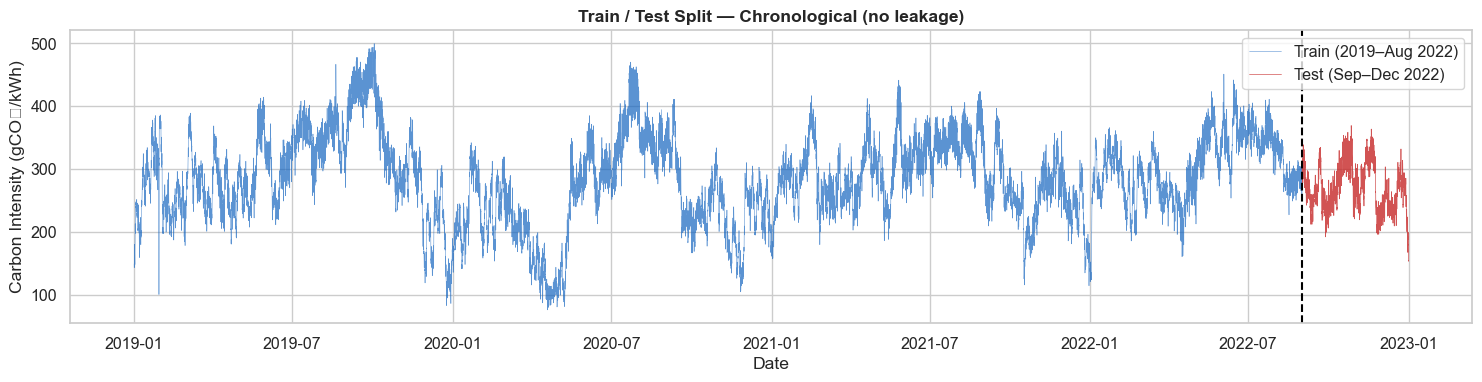

In [3]:
# Visualise the split
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(train['datetime'], train['carbon_intensity_gCO2_per_kWh'],
        color=BLUE, lw=0.4, alpha=0.7, label='Train (2019–Aug 2022)')
ax.plot(test['datetime'], test['carbon_intensity_gCO2_per_kWh'],
        color=RED, lw=0.5, alpha=0.8, label='Test (Sep–Dec 2022)')
ax.axvline(pd.Timestamp('2022-09-01'), color='black', ls='--', lw=1.5)
ax.set_xlabel('Date'); ax.set_ylabel('Carbon Intensity (gCO₂/kWh)')
ax.set_title('Train / Test Split — Chronological (no leakage)', fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(EDA_DIR / 'fc_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2 · Fit models and run rolling-origin evaluation

Each model is fitted on the training set, then evaluated with rolling 48-hour  
forecasts across the test set. This cell takes ~2 minutes (SARIMA and Prophet  
are the slowest).

In [4]:
models = [BaselineForecaster(), SarimaForecaster(), ProphetForecaster(), XGBoostForecaster()]

all_preds = {}
metric_rows = []
for m in models:
    t0 = time.time()
    m.fit(train)
    preds = rolling_origin_eval(m, df, horizon=48, step=24)
    all_preds[m.name] = preds
    met = compute_metrics(preds['actual'], preds['predicted'], m.name)
    met['time_s'] = round(time.time() - t0, 1)
    metric_rows.append(met)
    print(f"  {m.name:<14} MAE={met['MAE']:6.2f}  RMSE={met['RMSE']:6.2f}  MAPE={met['MAPE']:5.2f}%  ({met['time_s']}s)")

print('\nDone.')

  Naive (24h)    MAE= 19.27  RMSE= 25.41  MAPE= 7.35%  (0.2s)
2026-06-03 22:03:03  INFO      src.models.forecaster    SARIMA fitting on last 2160 hours …


  SARIMA         MAE= 20.60  RMSE= 26.36  MAPE= 7.95%  (65.2s)
2026-06-03 22:04:08  INFO      src.models.forecaster    Prophet fitting on trailing 180-day window …


22:04:08 - cmdstanpy - INFO - Chain [1] start processing


22:04:08 - cmdstanpy - INFO - Chain [1] done processing


22:04:08 - cmdstanpy - INFO - Chain [1] start processing


...

22:04:52 - cmdstanpy - INFO - Chain [1] start processing


22:04:52 - cmdstanpy - INFO - Chain [1] done processing


  Prophet        MAE= 30.39  RMSE= 37.94  MAPE=11.48%  (44.4s)


2026-06-03 22:04:52  INFO      src.models.forecaster    XGBoost fitting on 31,968 rows × 27 features …


  XGBoost        MAE= 17.95  RMSE= 23.80  MAPE= 6.80%  (9.7s)

Done.


---
## 3 · Comparison table

In [5]:
comp = pd.DataFrame(metric_rows).set_index('model').sort_values('MAE')
naive_mae = comp.loc['Naive (24h)', 'MAE']
comp['vs_naive_%'] = ((comp['MAE'] - naive_mae) / naive_mae * 100).round(1)
comp.to_csv(EDA_DIR / 'forecast_comparison.csv')
display(comp[['MAE','RMSE','MAPE','vs_naive_%','time_s']])

best = comp.index[0]
print(f'\nBest model by MAE: {best}  ({comp.loc[best,"MAE"]:.2f} gCO₂/kWh, '
      f'{abs(comp.loc[best,"vs_naive_%"]):.1f}% better than naive)')

,MAE,RMSE,MAPE,vs_naive_%,time_s
model,,,,,
XGBoost,17.953,23.805,6.804,-6.8,9.7
Naive (24h),19.270,25.408,7.350,0.0,0.2
SARIMA,20.603,26.356,7.953,6.9,65.2
Prophet,30.390,37.935,11.485,57.7,44.4



Best model by MAE: XGBoost  (17.95 gCO₂/kWh, 6.8% better than naive)


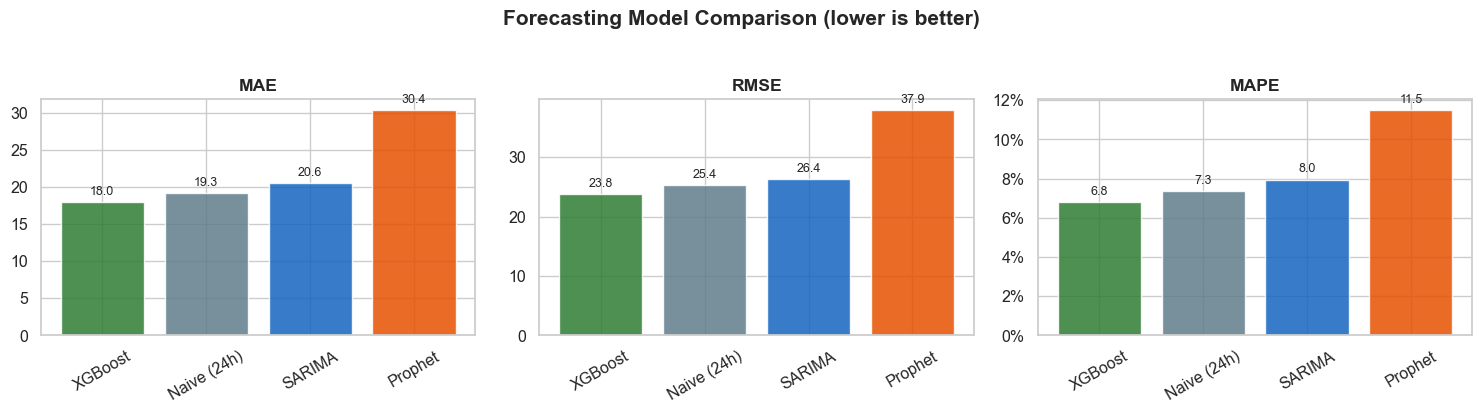

In [6]:
# Bar chart of the three metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE']):
    order = comp.sort_values(metric)
    colours = [MODEL_COLOURS[m] for m in order.index]
    bars = ax.bar(order.index, order[metric], color=colours, alpha=0.85)
    ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
    ax.set_title(metric, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    if metric == 'MAPE':
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.suptitle('Forecasting Model Comparison (lower is better)', fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(EDA_DIR / 'fc_metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4 · Error by forecast horizon

**The key diagnostic.** A 48-hour forecast is not uniformly difficult — error grows  
with how far ahead we predict. This reveals *where* each model adds value.

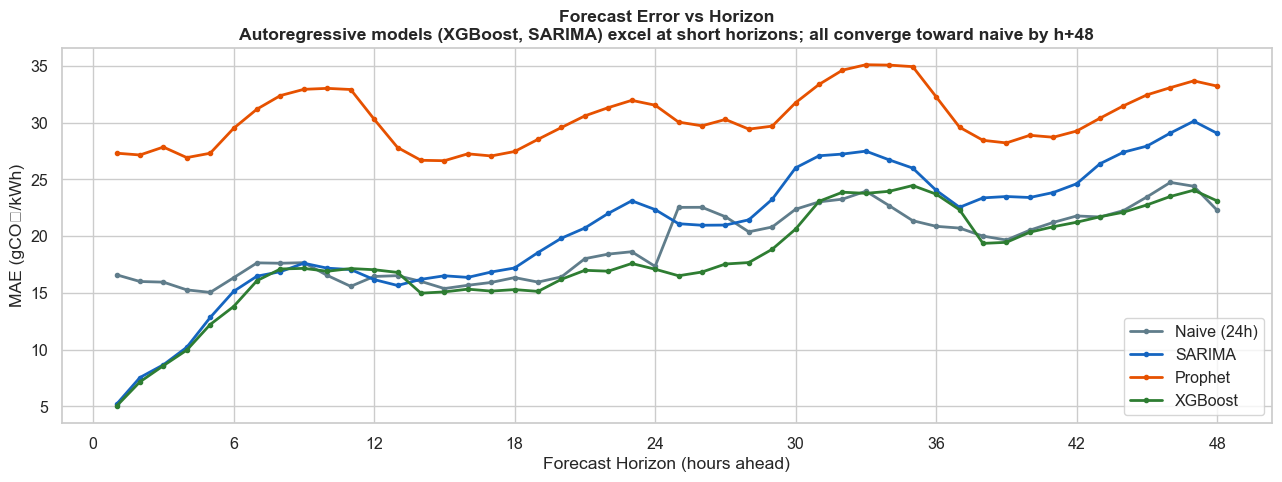

MAE by horizon band:


,Naive (24h),SARIMA,Prophet,XGBoost
h+1 to 6,15.87,9.93,27.67,9.46
h+7 to 24,16.78,18.15,29.96,16.33
h+25 to 48,22.01,25.15,31.40,21.32


In [7]:
fig, ax = plt.subplots(figsize=(13, 5))
for model, preds in all_preds.items():
    by_h = preds.groupby('horizon_h').apply(
        lambda g: np.mean(np.abs(g['actual'] - g['predicted'])))
    ax.plot(by_h.index, by_h.values, lw=2, marker='o', ms=3,
            color=MODEL_COLOURS[model], label=model)

ax.set_xlabel('Forecast Horizon (hours ahead)')
ax.set_ylabel('MAE (gCO₂/kWh)')
ax.set_title('Forecast Error vs Horizon\n'
             'Autoregressive models (XGBoost, SARIMA) excel at short horizons; '
             'all converge toward naive by h+48', fontweight='bold')
ax.legend(); ax.set_xticks(range(0, 49, 6))
plt.tight_layout()
plt.savefig(EDA_DIR / 'fc_error_by_horizon.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabulate by horizon band
print('MAE by horizon band:')
bands = [('h+1 to 6',1,6),('h+7 to 24',7,24),('h+25 to 48',25,48)]
tbl = {}
for model, preds in all_preds.items():
    tbl[model] = {name: round(np.mean(np.abs(
        (s:=preds[(preds.horizon_h>=lo)&(preds.horizon_h<=hi)])['actual']-s['predicted'])),2)
        for name,lo,hi in bands}
display(pd.DataFrame(tbl))

---
## 5 · Example 48-hour forecasts

A sample forecast window from each model against the actual carbon intensity,  
so the qualitative behaviour is visible — not just the aggregate metrics.

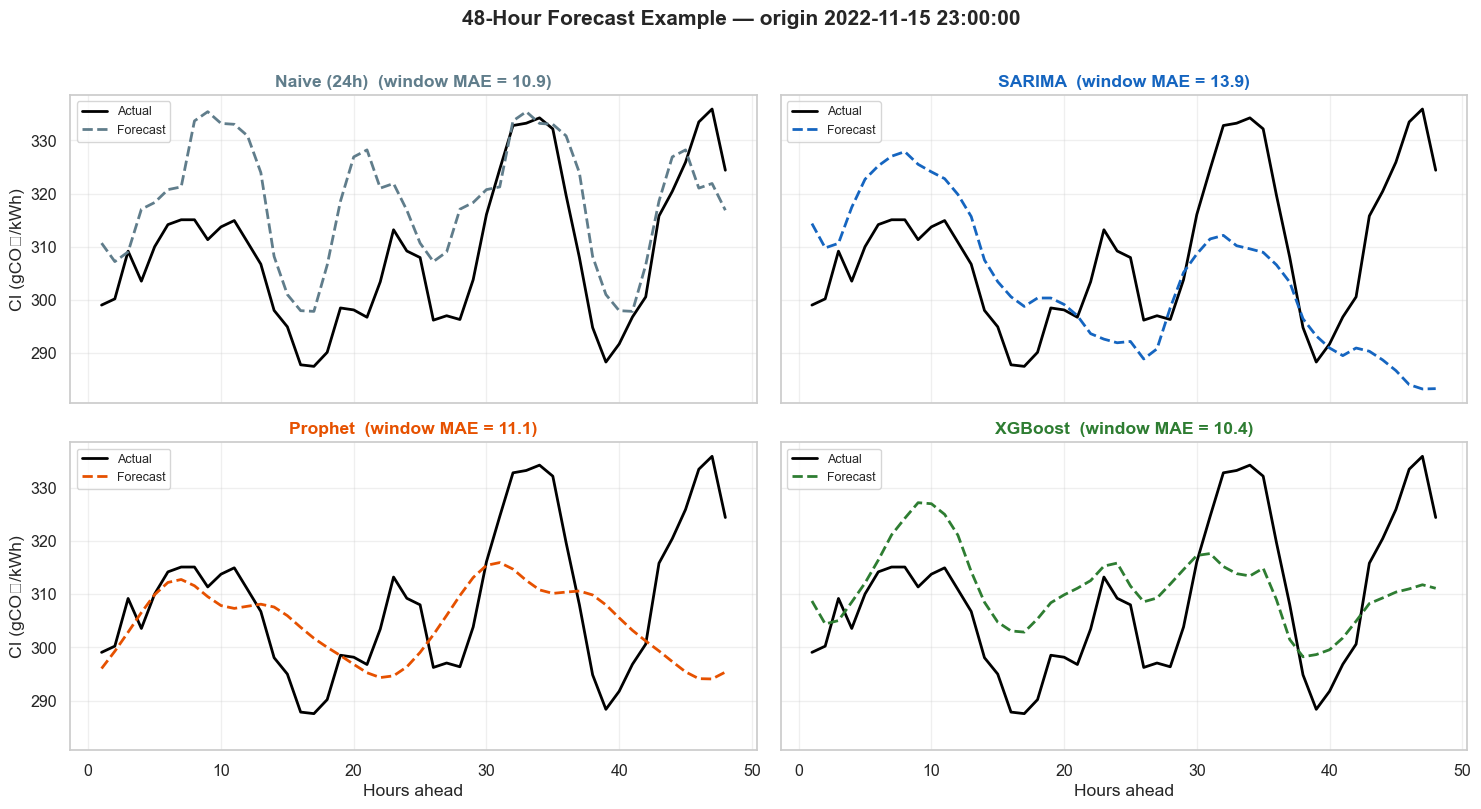

In [8]:
# Pick one representative origin in the test set
sample_origin = pd.Timestamp('2022-11-15 23:00:00')

fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True, sharey=True)
for ax, (model, preds) in zip(axes.flat, all_preds.items()):
    win = preds[preds['origin'] == sample_origin].sort_values('horizon_h')
    if len(win) == 0:
        # fall back to nearest available origin
        nearest = preds['origin'].iloc[(preds['origin'] - sample_origin).abs().argmin()]
        win = preds[preds['origin'] == nearest].sort_values('horizon_h')
    ax.plot(win['horizon_h'], win['actual'],    color='black', lw=2, label='Actual')
    ax.plot(win['horizon_h'], win['predicted'], color=MODEL_COLOURS[model],
            lw=2, ls='--', label='Forecast')
    mae = np.mean(np.abs(win['actual'] - win['predicted']))
    ax.set_title(f'{model}  (window MAE = {mae:.1f})', fontweight='bold',
                 color=MODEL_COLOURS[model])
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel('Hours ahead')
for ax in axes[:, 0]:
    ax.set_ylabel('CI (gCO₂/kWh)')
plt.suptitle(f'48-Hour Forecast Example — origin {sample_origin}', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(EDA_DIR / 'fc_example_windows.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6 · XGBoost feature importance

Which predictors drive the winning model's forecasts?

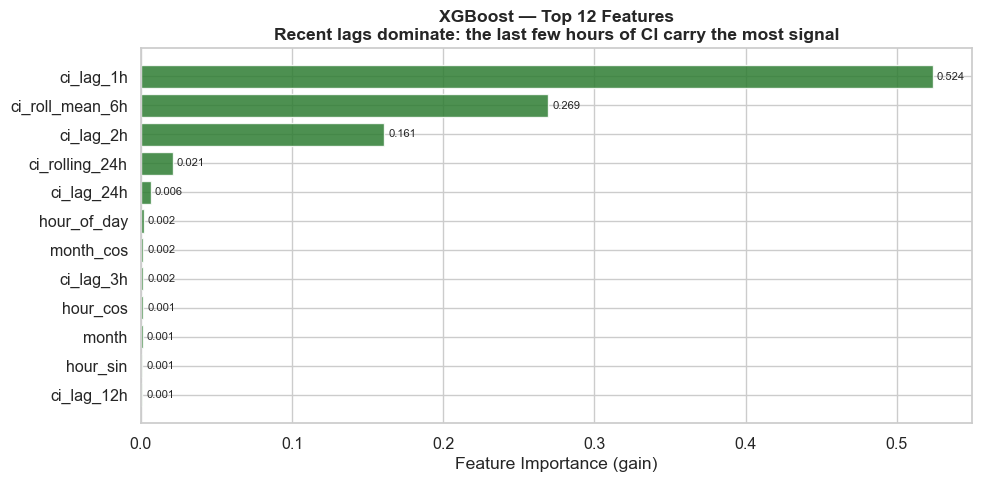

Top 5 features:
ci_lag_1h          0.5238
ci_roll_mean_6h    0.2693
ci_lag_2h          0.1608
ci_rolling_24h     0.0211
ci_lag_24h         0.0064


In [9]:
xgb = [m for m in models if m.name == 'XGBoost'][0]
imp = xgb.feature_importance().head(12)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(imp.index[::-1], imp.values[::-1], color=GREEN, alpha=0.85)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('XGBoost — Top 12 Features\n'
             'Recent lags dominate: the last few hours of CI carry the most signal',
             fontweight='bold')
plt.tight_layout()
plt.savefig(EDA_DIR / 'fc_xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Top 5 features:')
print(imp.head(5).round(4).to_string())

---
## 7 · Conclusion & model selection

In [10]:
print('═'*60)
print('  PHASE 3 — FORECASTING: CONCLUSION')
print('═'*60)
print(f'\n  Selected model: XGBoost')
print(f'    • Best overall MAE ({comp.loc["XGBoost","MAE"]:.2f} gCO₂/kWh), '
      f'{abs(comp.loc["XGBoost","vs_naive_%"]):.0f}% better than naive')
print(f'    • ~40% better than naive at short horizons (h+1 to 6)')
print(f'    • Fast to fit (~2s) and instant to predict')
print(f'\n  Key findings:')
print(f'    • The 24h-naive baseline is strong — TVA CI is highly daily-periodic')
print(f'    • Autoregressive models (XGBoost, SARIMA) win at short horizons where')
print(f'      recent CI carries signal; all converge to naive by h+48')
print(f'    • Prophet underperforms — being non-autoregressive, it ignores recent data')
print(f'\n  For the scheduler (Phase 4):')
print(f'    • Use XGBoost for the 48h point forecast')
print(f'    • Weight near-term hours more (forecast is most accurate there)')
print(f'    • Confidence bands will be built from empirical XGBoost error-by-horizon')
print(f'\n  Saved: data/processed/forecast_comparison.csv + 6 charts (fc_*.png)')
print('═'*60)

════════════════════════════════════════════════════════════
  PHASE 3 — FORECASTING: CONCLUSION
════════════════════════════════════════════════════════════

  Selected model: XGBoost
    • Best overall MAE (17.95 gCO₂/kWh), 7% better than naive
    • ~40% better than naive at short horizons (h+1 to 6)
    • Fast to fit (~2s) and instant to predict

  Key findings:
    • The 24h-naive baseline is strong — TVA CI is highly daily-periodic
    • Autoregressive models (XGBoost, SARIMA) win at short horizons where
      recent CI carries signal; all converge to naive by h+48
    • Prophet underperforms — being non-autoregressive, it ignores recent data

  For the scheduler (Phase 4):
    • Use XGBoost for the 48h point forecast
    • Weight near-term hours more (forecast is most accurate there)
    • Confidence bands will be built from empirical XGBoost error-by-horizon

  Saved: data/processed/forecast_comparison.csv + 6 charts (fc_*.png)
══════════════════════════════════════════════════